# UCI HAR Dataset Overview

This notebook provides an overview of the UCI Human Activity Recognition dataset.

The objectives are to:

1. understand the structure of the original dataset;
2. inspect the activity labels and subject identifiers;
3. examine the windowed inertial sensor signals;
4. visualise representative activity samples; and
5. identify data characteristics relevant to subsequent preprocessing and modelling.

No preprocessing transformations or model training are performed in this notebook.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
# Locate the project root whether the notebook is launched
# from the project directory or the notebooks directory.
PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

DATA_DIR = PROJECT_ROOT / "data" / "UCI_HAR"

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Dataset directory not found: {DATA_DIR}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset directory: {DATA_DIR}")

Project root: D:\Lunacia\Machine Learning
Dataset directory: D:\Lunacia\Machine Learning\data\UCI_HAR


## Activity Labels

The original dataset represents each activity using an integer from 1 to 6.
The label file maps these integers to human-readable activity names.

In [4]:
activity_labels = pd.read_csv(
    DATA_DIR / "activity_labels.txt",
    sep=r"\s+",
    names=["label", "activity"],
)

activity_labels

,label,activity
0,1,WALKING
1,2,WALKING_UPSTAIRS
2,3,WALKING_DOWNSTAIRS
3,4,SITTING
4,5,STANDING
5,6,LAYING


## Dataset File Structure

The training split contains labels, subject identifiers, engineered features, and raw inertial signals. Before loading the data, we inspect the available files and determine which representation is suitable for this project.

In [5]:
TRAIN_DIR = DATA_DIR / "train"

train_files = sorted(
    path.relative_to(DATA_DIR)
    for path in TRAIN_DIR.rglob("*")
    if path.is_file()
)

for path in train_files:
    print(path)

train\Inertial Signals\body_acc_x_train.txt
train\Inertial Signals\body_acc_y_train.txt
train\Inertial Signals\body_acc_z_train.txt
train\Inertial Signals\body_gyro_x_train.txt
train\Inertial Signals\body_gyro_y_train.txt
train\Inertial Signals\body_gyro_z_train.txt
train\Inertial Signals\total_acc_x_train.txt
train\Inertial Signals\total_acc_y_train.txt
train\Inertial Signals\total_acc_z_train.txt
train\subject_train.txt
train\X_train.txt
train\y_train.txt


## Inspecting a Single Sensor Channel

Each inertial signal file stores one sensor channel. Each row corresponds to one sample window, while the columns represent consecutive measurements within that window.

We first inspect the body acceleration along the x-axis.

In [6]:
body_acc_x = np.loadtxt(
    TRAIN_DIR / "Inertial Signals" / "body_acc_x_train.txt",
    dtype=np.float32,
)

print(f"Shape: {body_acc_x.shape}")
print("First 10 values of the first sample:")
print(body_acc_x[0, :10])

Shape: (7352, 128)
First 10 values of the first sample:
[0.00018085 0.01013856 0.00927557 0.0050659  0.01081025 0.0040451
 0.00475737 0.00621365 0.00330674 0.00757194]


## Visualising a Sensor Signal

The sensor was sampled at 50 Hz, meaning that 50 measurements were recorded per second. A window containing 128 measurements therefore covers approximately 2.56 seconds.

The following plot shows the body acceleration along the x-axis for the first training sample.

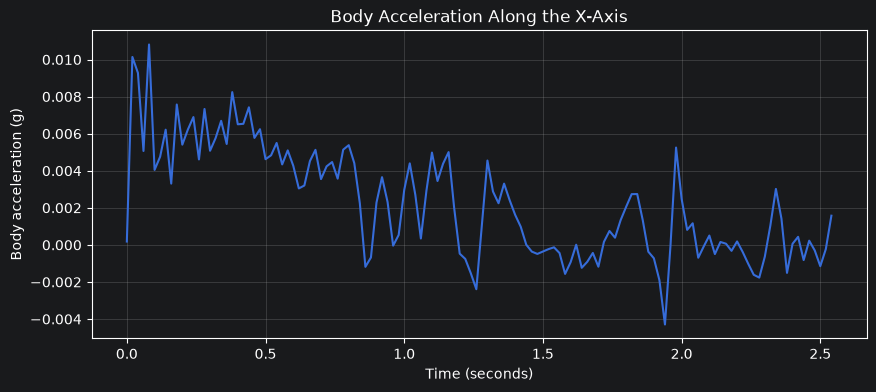

In [7]:
SAMPLING_RATE = 50

time_seconds = np.arange(body_acc_x.shape[1]) / SAMPLING_RATE

plt.figure(figsize=(10, 4))
plt.plot(time_seconds, body_acc_x[0])

plt.title("Body Acceleration Along the X-Axis")
plt.xlabel("Time (seconds)")
plt.ylabel("Body acceleration (g)")
plt.grid(alpha=0.3)
plt.show()

## Loading Labels and Subject Identifiers

Each sensor window has two associated values:

- an activity label describing the activity performed; and
- a subject identifier indicating the participant who produced the data.

These values allow us to connect each sensor signal with its activity and participant.

In [8]:
y_train = np.loadtxt(
    TRAIN_DIR / "y_train.txt",
    dtype=np.int64,
)

subject_train = np.loadtxt(
    TRAIN_DIR / "subject_train.txt",
    dtype=np.int64,
)

print(f"Number of labels: {y_train.shape[0]}")
print(f"Number of subject identifiers: {subject_train.shape[0]}")
print(f"Number of sensor samples: {body_acc_x.shape[0]}")

Number of labels: 7352
Number of subject identifiers: 7352
Number of sensor samples: 7352


In [9]:
label_to_activity = dict(
    zip(activity_labels["label"], activity_labels["activity"])
)

sample_index = 0
sample_label = y_train[sample_index]
sample_subject = subject_train[sample_index]
sample_activity = label_to_activity[sample_label]

print(f"Sample index: {sample_index}")
print(f"Subject: {sample_subject}")
print(f"Original label: {sample_label}")
print(f"Activity: {sample_activity}")

Sample index: 0
Subject: 1
Original label: 5
Activity: STANDING


## Combining the Sensor Channels

The raw inertial data are stored in nine separate files. Each file has the shape `(7352, 128)`, representing 7,352 sample windows with 128 time steps.

We combine the nine files into a single three-dimensional array with the shape:

`(samples, time steps, sensor channels)`

In [10]:
SENSOR_CHANNELS = [
    "body_acc_x",
    "body_acc_y",
    "body_acc_z",
    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",
    "total_acc_x",
    "total_acc_y",
    "total_acc_z",
]

SENSOR_CHANNELS

['body_acc_x',
 'body_acc_y',
 'body_acc_z',
 'body_gyro_x',
 'body_gyro_y',
 'body_gyro_z',
 'total_acc_x',
 'total_acc_y',
 'total_acc_z']

In [11]:
train_signals = []

for channel in SENSOR_CHANNELS:
    file_path = (
        TRAIN_DIR
        / "Inertial Signals"
        / f"{channel}_train.txt"
    )

    signal = np.loadtxt(file_path, dtype=np.float32)
    train_signals.append(signal)

    print(f"{channel}: {signal.shape}")

body_acc_x: (7352, 128)
body_acc_y: (7352, 128)
body_acc_z: (7352, 128)
body_gyro_x: (7352, 128)
body_gyro_y: (7352, 128)
body_gyro_z: (7352, 128)
total_acc_x: (7352, 128)
total_acc_y: (7352, 128)
total_acc_z: (7352, 128)


In [12]:
X_train_raw = np.stack(train_signals, axis=-1)

print(f"Combined training data shape: {X_train_raw.shape}")

Combined training data shape: (7352, 128, 9)


## Inspecting a Complete Sample Window

After combining the sensor files, each sample contains 128 time steps and 9 sensor channels.

The following table displays the first training sample. Each row represents one point in time, while each sensor channel is stored in a separate column.

In [13]:
sample_index = 0

sample_table = pd.DataFrame(
    X_train_raw[sample_index],
    columns=SENSOR_CHANNELS,
)

sample_table.insert(
    0,
    "time_seconds",
    np.arange(X_train_raw.shape[1]) / SAMPLING_RATE,
)

print(f"Subject: {subject_train[sample_index]}")
print(f"Activity: {label_to_activity[y_train[sample_index]]}")
print(f"Sample shape: {X_train_raw[sample_index].shape}")

sample_table.head(10)

Subject: 1
Activity: STANDING
Sample shape: (128, 9)


,time_seconds,body_acc_x,body_acc_y,body_acc_z,body_gyro_x,body_gyro_y,body_gyro_z,total_acc_x,total_acc_y,total_acc_z
0,0.00,0.000181,0.010767,0.055561,0.030191,0.066014,0.022859,1.012817,-0.123217,0.102934
1,0.02,0.010139,0.006579,0.055125,0.043711,0.042699,0.010316,1.022833,-0.126876,0.105687
2,0.04,0.009276,0.008929,0.048405,0.035688,0.074850,0.013250,1.022028,-0.124004,0.102103
3,0.06,0.005066,0.007489,0.049775,0.040402,0.057320,0.017751,1.017877,-0.124928,0.106553
4,0.08,0.010810,0.006141,0.043013,0.047097,0.052343,0.002553,1.023680,-0.125767,0.102813
5,0.10,0.004045,0.006944,0.044729,0.050185,0.069174,0.007725,1.016974,-0.124462,0.107493
6,0.12,0.004757,0.003552,0.043719,0.050545,0.049867,0.004325,1.017746,-0.127361,0.109386
7,0.14,0.006214,0.002537,0.035379,0.044992,0.056751,0.010617,1.019263,-0.127891,0.103886
8,0.16,0.003307,0.004085,0.031188,0.047686,0.058189,0.017189,1.016417,-0.125868,0.102473
9,0.18,0.007572,0.005118,0.023567,0.046812,0.043199,0.010511,1.020745,-0.124368,0.097566


## Visualising a Complete Sample Window

The nine sensor channels are divided into three groups:

- body acceleration, which describes motion after the estimated gravity component has been removed;
- gyroscope measurements, which describe angular velocity; and
- total acceleration, which includes both body motion and gravity.

The channels are plotted separately to make their temporal patterns easier to interpret.

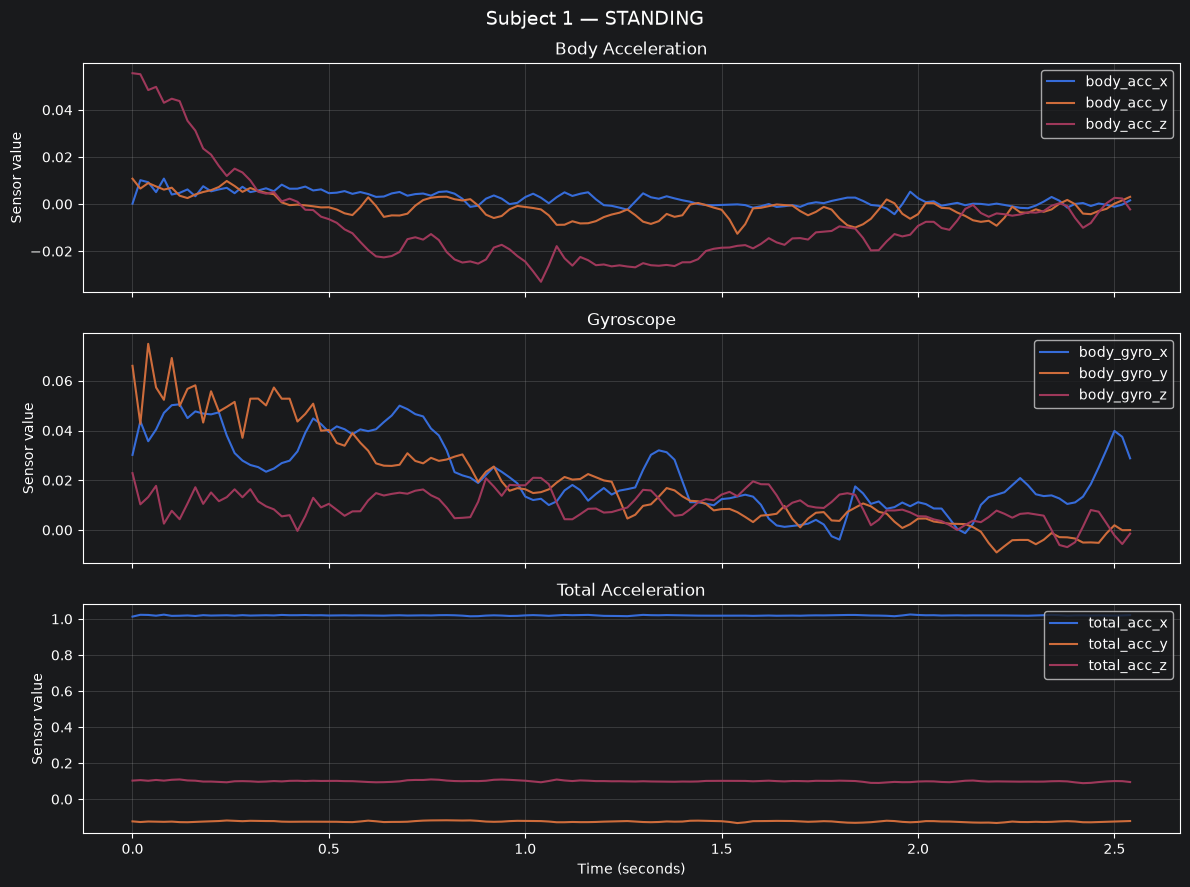

In [14]:
channel_groups = {
    "Body Acceleration": [
        "body_acc_x",
        "body_acc_y",
        "body_acc_z",
    ],
    "Gyroscope": [
        "body_gyro_x",
        "body_gyro_y",
        "body_gyro_z",
    ],
    "Total Acceleration": [
        "total_acc_x",
        "total_acc_y",
        "total_acc_z",
    ],
}

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 9),
    sharex=True,
)

for ax, (group_name, channels) in zip(
    axes,
    channel_groups.items(),
):
    for channel in channels:
        ax.plot(
            sample_table["time_seconds"],
            sample_table[channel],
            label=channel,
        )

    ax.set_title(group_name)
    ax.set_ylabel("Sensor value")
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time (seconds)")

fig.suptitle(
    f"Subject {subject_train[sample_index]} — "
    f"{label_to_activity[y_train[sample_index]]}",
    fontsize=14,
)

plt.tight_layout()
plt.show()

## Comparing Different Activities

To obtain an initial visual understanding of the dataset, one sample is selected from each activity class.

For this comparison, the three body-acceleration axes are combined into a single magnitude:

$$
\text{magnitude} = \sqrt{x^2 + y^2 + z^2}
$$

This derived value is used only for visualisation. The model input will retain all nine original sensor channels.

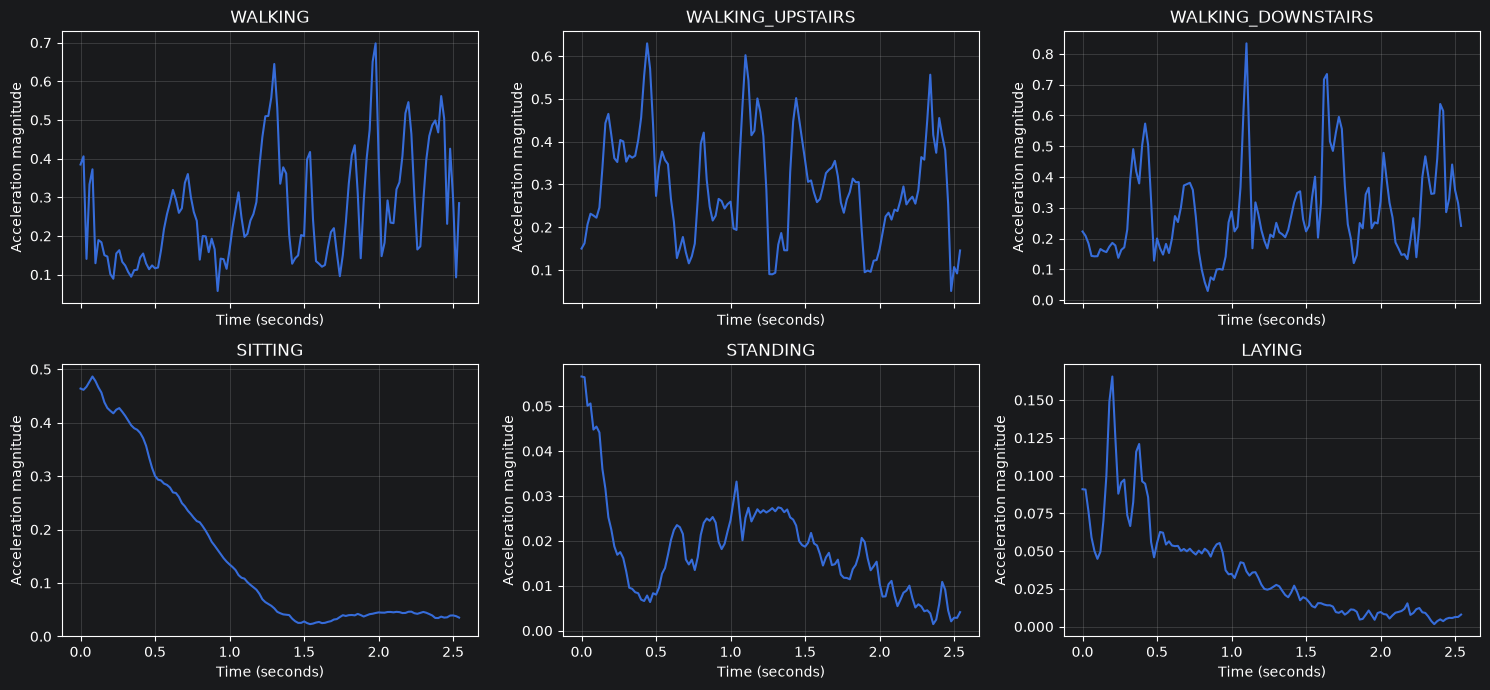

In [15]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 7),
    sharex=True,
)

for label, ax in zip(
    activity_labels["label"],
    axes.flat,
):
    activity_name = label_to_activity[label]

    # Select the first sample belonging to this activity.
    activity_sample_index = np.flatnonzero(
        y_train == label
    )[0]

    body_acceleration = X_train_raw[
        activity_sample_index,
        :,
        0:3,
    ]

    body_acceleration_magnitude = np.linalg.norm(
        body_acceleration,
        axis=1,
    )

    ax.plot(
        time_seconds,
        body_acceleration_magnitude,
    )

    ax.set_title(activity_name)
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Acceleration magnitude")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

The UCI HAR dataset contains fixed-length smartphone sensor windows representing six human activities.

Each sample contains:

- 128 consecutive time steps;
- 9 inertial sensor channels;
- one activity label; and
- one subject identifier.

The exploratory visualisations suggest that dynamic and static activities exhibit different temporal patterns. However, individual samples are not sufficient to determine how reliably the activities can be classified.

The next notebook will construct a reproducible preprocessing pipeline, including data loading, label conversion, subject-based validation, normalisation, and integrity checks.